<a href="https://colab.research.google.com/github/apeas1/PIDDeteccionVehiculos/blob/main/Obtencion_de_metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install -qq ultralytics
from ultralytics import YOLO
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
!git config --global user.name "usuario"
!git config --global user.email "correo"

In [3]:
!git clone https://token@github.com/apeas1/PIDDeteccionVehiculos.git

Cloning into 'PIDDeteccionVehiculos'...
remote: Enumerating objects: 5021, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 5021 (delta 0), reused 0 (delta 0), pack-reused 5018 (from 3)
Receiving objects: 100% (5021/5021), 396.40 MiB | 39.93 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (7432/7432), done.


In [9]:
cd PIDDeteccionVehiculos

/content/PIDDeteccionVehiculos


In [11]:
#MÉTRICAS TEST
model = YOLO("Modelos/Entrenamiento2010_dataaug/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1415.5±309.8 MB/s, size: 93.8 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 390.8it/s 0.6s
val: New cache created: /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.8s/it 1:32
                   all        252      27305      0.652      0.618      0.644      0.304
                    3W        251       2972      0.727       0.59      0.613      0.215
                   Bus        125        364      0.674      0.852      0.846      0.493
                 Coche        251       8362      0.751      0.836      0.823      0.372
             Ca

Para el modelo entrenado con 20 epochs, tamaño de batch de 10 y data augmentation
Precisión: 0.6515948247527356
Recall: 0.6184169413322932
F1 score: 0.6194110941344795
Matriz de confusión:


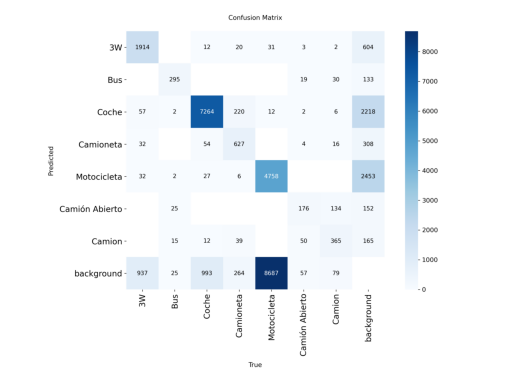

In [12]:
img = mpimg.imread('runs/detect/val/confusion_matrix.png')
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 10 y data augmentation")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img)
plt.axis('off')
plt.show()

In [13]:
#MÉTRICAS TEST
model = YOLO("Modelos/Entrenamiento2010/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test



Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2274.5±596.8 MB/s, size: 93.8 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 323.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.9s/it 1:34
                   all        252      27305      0.732       0.73      0.763      0.408
                    3W        251       2972      0.779      0.703      0.753      0.294
                   Bus        125        364      0.824       0.86      0.915      0.599
                 Coche        251       8362      0.834      0.907      0.901      0.467
             Camioneta        182       1176       0.73      0.709      0.758      0.422
           M

Para el modelo entrenado con 20 epochs, tamaño de batch de 10
Precisión: 0.7322309779143846
Recall: 0.7302904508316461
F1 score: 0.721103932554634
Matriz de confusión:


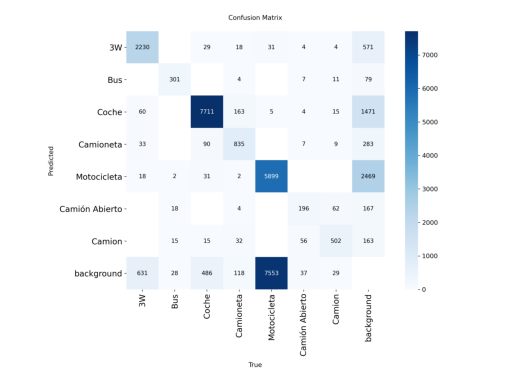

In [25]:
img2 = mpimg.imread('runs/detect/val2/confusion_matrix.png')
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 10")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img2)
plt.axis('off')
plt.show()

In [26]:
#MÉTRICAS TEST
model = YOLO("Modelos/Entrenamiento308/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test



Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1089.1±778.9 MB/s, size: 83.8 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 319.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.5s/it 1:44
                   all        252      27305      0.738      0.787      0.793       0.44
                    3W        251       2972       0.79      0.764       0.79      0.331
                   Bus        125        364      0.839      0.945      0.932      0.646
                 Coche        251       8362      0.846      0.925      0.922      0.497
             Camioneta        182       1176      0.742      0.754      0.792      0.449
           M

Para el modelo entrenado con 30 epochs, tamaño de batch de 8
Precisión: 0.7378976443247127
Recall: 0.7872683028524462
F1 score: 0.7540966315038802
Matriz de confusión:


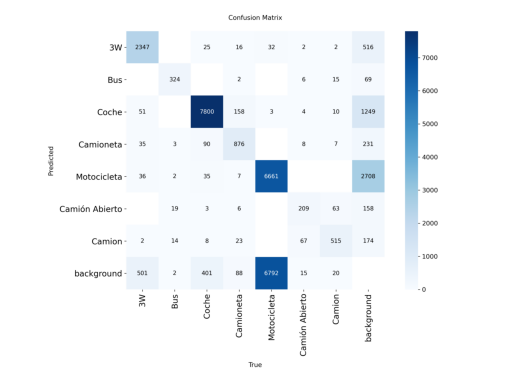

In [27]:
img3 = mpimg.imread('runs/detect/val3/confusion_matrix.png')
print("Para el modelo entrenado con 30 epochs, tamaño de batch de 8")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img3)
plt.axis('off')
plt.show()

In [28]:
#MÉTRICAS TEST
model = YOLO("Modelos/Entrenamiento2025/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test



Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2204.7±713.4 MB/s, size: 88.7 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 298.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.9s/it 1:34
                   all        252      27305      0.737      0.751      0.773       0.42
                    3W        251       2972      0.785      0.711      0.762      0.303
                   Bus        125        364      0.848      0.931      0.935      0.631
                 Coche        251       8362      0.829      0.916      0.907      0.474
             Camioneta        182       1176      0.778      0.692      0.767      0.432
           M

Para el modelo entrenado con 20 epochs, tamaño de batch de 25
Precisión: 0.7371159203924007
Recall: 0.750553565273125
F1 score: 0.7343617183823593
Matriz de confusión:


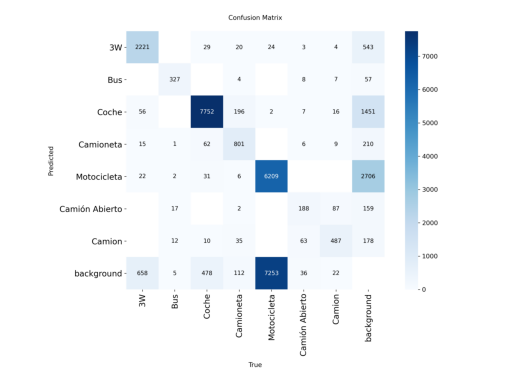

In [29]:
img4 = mpimg.imread('runs/detect/val4/confusion_matrix.png')
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 25")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img4)
plt.axis('off')
plt.show()

In [30]:
#MÉTRICAS TEST
model = YOLO("Modelos/weights_dataAug_1/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test



Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1874.5±402.3 MB/s, size: 92.8 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 271.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.6s/it 1:30
                   all        252      27305      0.633      0.616       0.63      0.293
                    3W        251       2972      0.704      0.563      0.597      0.203
                   Bus        125        364      0.615      0.907       0.86      0.481
                 Coche        251       8362      0.728      0.831      0.807      0.365
             Camioneta        182       1176      0.602       0.47      0.547      0.261
           M

Para el modelo entrenado con 20 epochs, tamaño de batch de 25, con data augmentation
Precisión: 0.6328081952748177
Recall: 0.6159481010547773
F1 score: 0.6093742572804157
Matriz de confusión:


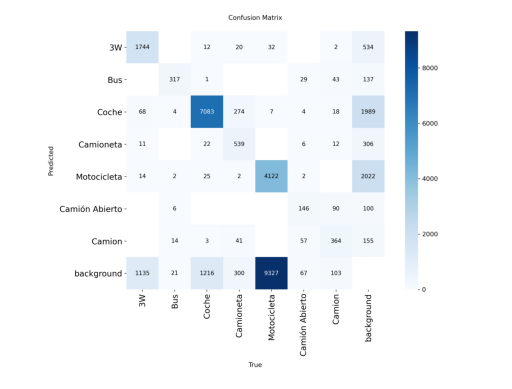

In [31]:
img5 = mpimg.imread('runs/detect/val5/confusion_matrix.png')
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 25, con data augmentation")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img5)
plt.axis('off')
plt.show()

In [32]:
#MÉTRICAS TEST
model = YOLO("Modelos/weights_no_dataAug/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test



Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1090.2±240.9 MB/s, size: 81.9 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 242.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.1s/it 1:38
                   all        252      27305      0.735      0.718      0.749      0.401
                    3W        251       2972      0.759      0.678      0.726      0.283
                   Bus        125        364       0.82      0.909      0.917       0.61
                 Coche        251       8362       0.83      0.894      0.896      0.459
             Camioneta        182       1176      0.775      0.673      0.739       0.41
           M

Para el modelo entrenado con 20 epochs, tamaño de batch de 25 y sin data augmentation
Precisión: 0.7353996975005437
Recall: 0.7178874863373129
F1 score: 0.7191027793993391
Matriz de confusión:


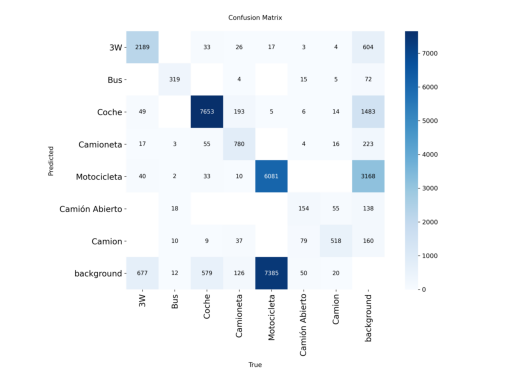

In [33]:
img6 = mpimg.imread('runs/detect/val6/confusion_matrix.png')
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 25 y sin data augmentation")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img6)
plt.axis('off')
plt.show()

In [34]:
model = YOLO("/content/PIDDeteccionVehiculos/Modelos/modelo_15_30_0.5_0.6/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test



Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1950.0±357.7 MB/s, size: 90.5 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 332.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.0s/it 1:35
                   all        252      27305      0.745      0.706      0.753      0.405
                    3W        251       2972      0.775      0.679      0.732      0.284
                   Bus        125        364      0.784       0.89      0.904      0.605
                 Coche        251       8362       0.84      0.894      0.899      0.463
             Camioneta        182       1176       0.78      0.664      0.744      0.414
           M

Para el modelo entrenado con  epochs, tamaño de batch de  y sin data augmentation
Precisión: 0.7452380737282673
Recall: 0.7062776974140498
F1 score: 0.7165963878349562
Matriz de confusión:


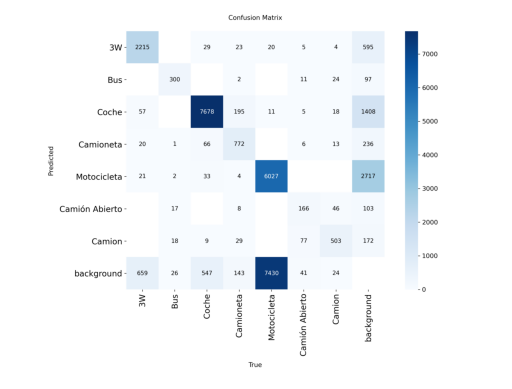

In [35]:
img7 = mpimg.imread('runs/detect/val7/confusion_matrix.png')
print("Para el modelo entrenado con  epochs, tamaño de batch de  y sin data augmentation")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img7)
plt.axis('off')
plt.show()

In [36]:
model = YOLO("Modelos/modelo_15_40(best).pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test



Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1921.9±394.7 MB/s, size: 95.0 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 323.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.9s/it 1:35
                   all        252      27305      0.717      0.716      0.739      0.388
                    3W        251       2972      0.768      0.657      0.711      0.268
                   Bus        125        364       0.77      0.942      0.929      0.605
                 Coche        251       8362       0.82      0.897      0.889      0.443
             Camioneta        182       1176      0.745      0.677      0.735      0.403
           M

Para el modelo entrenado con  epochs, tamaño de batch de  y sin data augmentation
Precisión: 0.7168078304428226
Recall: 0.7159176344220048
F1 score: 0.705244211029847
Matriz de confusión:


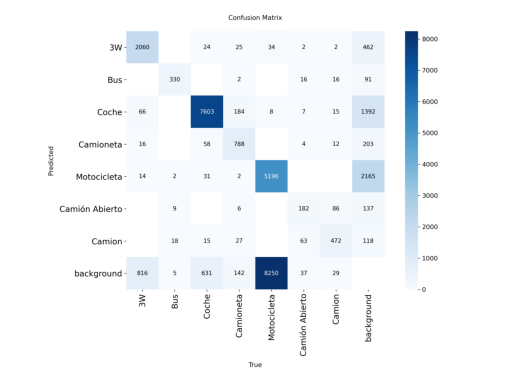

In [37]:
img8 = mpimg.imread('runs/detect/val8/confusion_matrix.png')
print("Para el modelo entrenado con  epochs, tamaño de batch de  y sin data augmentation")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img8)
plt.axis('off')
plt.show()

In [38]:
model = YOLO("Modelos/modelo_dataset_antiguo/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test



Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1882.3±381.6 MB/s, size: 85.0 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 321.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.2s/it 1:23
                   all        252      27305     0.0378      0.125     0.0248     0.0119
                   PMT        251       2972          0          0          0          0
        Bus Articulado        125        364      0.104      0.234     0.0709     0.0379
                   Bus        251       8362      0.082     0.0346     0.0427     0.0184
                 Coche        182       1176     0.0381      0.383     0.0298     0.0111
            

Para el modelo entrenado con  epochs, tamaño de batch de  y sin data augmentation
Precisión: 0.03777412123512441
Recall: 0.12535062448604514
F1 score: 0.047063188740689085
Matriz de confusión:


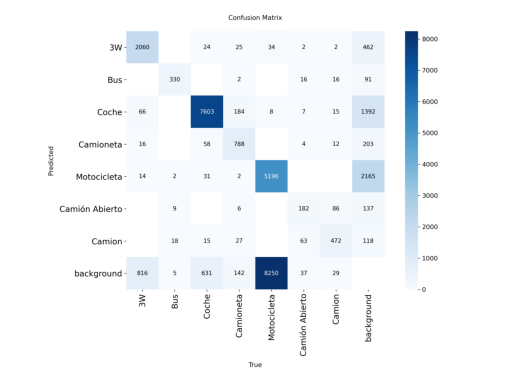

In [39]:
img9 = mpimg.imread('runs/detect/val9/confusion_matrix.png')
print("Para el modelo entrenado con el otro dataset que consideramos utilizar")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img8)
plt.axis('off')
plt.show()

In [39]:
rm -rf runs

In [40]:
!git add runs

In [41]:
!git commit -m "Adición resultado de obtener métricas sobre el conjunto de test de los modelos"

[main 64486c4] Adición resultado de obtener métricas sobre el conjunto de test de los modelos
 108 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 runs/detect/val/BoxF1_curve.png
 create mode 100644 runs/detect/val/BoxPR_curve.png
 create mode 100644 runs/detect/val/BoxP_curve.png
 create mode 100644 runs/detect/val/BoxR_curve.png
 create mode 100644 runs/detect/val/confusion_matrix.png
 create mode 100644 runs/detect/val/confusion_matrix_normalized.png
 create mode 100644 runs/detect/val/val_batch0_labels.jpg
 create mode 100644 runs/detect/val/val_batch0_pred.jpg
 create mode 100644 runs/detect/val/val_batch1_labels.jpg
 create mode 100644 runs/detect/val/val_batch1_pred.jpg
 create mode 100644 runs/detect/val/val_batch2_labels.jpg
 create mode 100644 runs/detect/val/val_batch2_pred.jpg
 create mode 100644 runs/detect/val2/BoxF1_curve.png
 create mode 100644 runs/detect/val2/BoxPR_curve.png
 create mode 100644 runs/detect/val2/BoxP_curve.png
 create mode 100644 run

In [42]:
!git push origin main

Enumerating objects: 101, done.
Counting objects: 100% (101/101), done.
Delta compression using up to 2 threads
Compressing objects: 100% (99/99), done.
Writing objects: 100% (100/100), 47.31 MiB | 12.99 MiB/s, done.
Total 100 (delta 8), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (8/8), completed with 1 local object.
To https://github.com/apeas1/PIDDeteccionVehiculos.git
   fb51c17..64486c4  main -> main


In [8]:
!cp -r "/content/drive/MyDrive/Modelos/modelo_15_40(best).pt" "/content/PIDDeteccionVehiculos/Modelos/"